# THỰC HÀNH 2.2: SUPPORT VECTOR MACHINE (SVM)


**Mục tiêu:**
- Hiểu và huấn luyện SVM với `sklearn.svm.SVC`; so sánh các kernel; hiểu vai trò của `C` và `gamma`.
- Bài toán 1: phân loại hoa **Iris** (dữ liệu có sẵn trong scikit-learn).
- Bài toán 2: nhận diện **chữ số viết tay** 0–9 (`load_digits`, ảnh 8×8).
- Đánh giá bằng accuracy, confusion matrix, precision / recall / F1; tối ưu tham số bằng `GridSearchCV`.

## 0. Ôn tập lý thuyết
| Khái niệm | Tóm tắt |
|---|---|
| **Siêu phẳng (hyperplane) & lề (margin)** | SVM tìm siêu phẳng phân tách hai lớp sao cho **lề** (khoảng cách tới điểm gần nhất của mỗi lớp) là lớn nhất. |
| **Support vectors** | Các điểm nằm sát biên/lề; chỉ các điểm này quyết định vị trí siêu phẳng, các điểm khác bỏ đi cũng không đổi mô hình. |
| **Hard margin / Soft margin** | Hard margin: không cho phân loại sai, chỉ dùng khi dữ liệu tách tuyến tính hoàn hảo. Soft margin: cho phép sai số (biến slack) → dùng khi dữ liệu có nhiễu/chồng lấn (thực tế). |
| **Tham số C** | Hệ số phạt lỗi. C lớn → lề hẹp, ít sai trên train nhưng dễ quá khớp. C nhỏ → lề rộng, mô hình đơn giản hơn, có thể chưa khớp (underfit). |
| **Kernel** | Hàm ánh xạ ngầm sang không gian cao chiều. `linear`: dữ liệu gần tuyến tính; `poly`: quan hệ đa thức; `rbf`: mặc định, linh hoạt, cần chỉnh `gamma`; `sigmoid`: ít dùng. |
| **gamma (RBF)** | gamma lớn → mỗi điểm ảnh hưởng hẹp, ranh giới phức tạp, dễ quá khớp; gamma nhỏ → ranh giới mượt. |
| **Chuẩn hóa dữ liệu** | SVM dựa trên khoảng cách nên rất nhạy với thang đo → dùng `StandardScaler` (hoặc `MinMaxScaler`) trước khi huấn luyện. |

## 1. Nạp thư viện

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")
OUT_DIR = Path("ket_qua")
OUT_DIR.mkdir(exist_ok=True)

# BÀI TOÁN 1: Phân loại hoa Iris


## Nhiệm vụ 1.1: Nạp dữ liệu và chuẩn bị

In [2]:
iris = datasets.load_iris()
print(iris.DESCR[:1500]) 

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
data, target = iris.data, iris.target
print("Đặc trưng:", iris.feature_names)
print("Các lớp  :", [str(c) for c in iris.target_names])
print("Kích thước:", data.shape)
pd.DataFrame(data, columns=iris.feature_names).describe().round(2)

Đặc trưng: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Các lớp  : ['setosa', 'versicolor', 'virginica']
Kích thước: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.2, random_state=101)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (120, 4) | Test: (30, 4)


## Nhiệm vụ 1.2: Mô hình SVM mặc định và đánh giá độ chính xác

In [5]:
clf = svm.SVC()
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
val_acc = clf.score(X_test, y_test)
print(f"Training accuracy  : {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Training accuracy  : 0.9500
Validation accuracy: 0.9667


## Nhiệm vụ 1.3: So sánh các kernel

Huấn luyện với 4 kernel và chọn kernel có độ chính xác cao nhất trên tập kiểm tra.

In [6]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
best_svm, best_val_acc, best_kernel = None, -1, None
rows = []
for k in kernels:
    m = svm.SVC(kernel=k)
    m.fit(X_train, y_train)
    tr, te = m.score(X_train, y_train), m.score(X_test, y_test)
    rows.append({"kernel": k, "train_acc": round(tr, 4), "test_acc": round(te, 4)})
    if te > best_val_acc:
        best_svm, best_val_acc, best_kernel = m, te, k

print(f"Best validation accuracy: {best_val_acc:.4f} with kernel: {best_kernel}")
pd.DataFrame(rows)

Best validation accuracy: 1.0000 with kernel: linear


,kernel,train_acc,test_acc
0,linear,0.9833,1.0000
1,poly,0.9833,1.0000
2,rbf,0.9500,0.9667
3,sigmoid,0.3500,0.2667


## Nhiệm vụ 1.4: `Pipeline` (chuẩn hóa) + `GridSearchCV`

Chọn kernel, `C`, `gamma` bằng cross-validation 5-fold **trên tập train**; tập test chỉ dùng đánh giá cuối.

In [7]:
pipe = Pipeline([("scaler", StandardScaler()), ("svc", svm.SVC())])
param_grid = {
    "svc__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
}
gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(X_train, y_train)

print("Tham số tốt nhất      :", gs.best_params_)
print(f"Accuracy CV (train)   : {gs.best_score_:.4f}")
print(f"Accuracy trên tập test: {gs.score(X_test, y_test):.4f}")

Tham số tốt nhất      : {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Accuracy CV (train)   : 0.9667
Accuracy trên tập test: 1.0000


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        12
   virginica       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



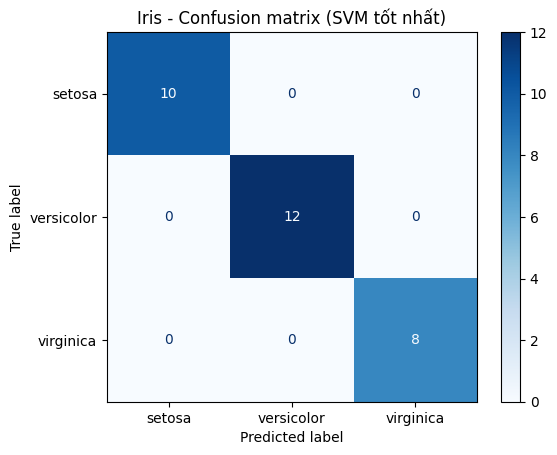

In [8]:
y_pred = gs.predict(X_test)
print(classification_report(y_test, y_pred, target_names=[str(c) for c in iris.target_names]))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=[str(c) for c in iris.target_names]).plot(cmap="Blues")
plt.title("Iris - Confusion matrix (SVM tốt nhất)")
plt.savefig(OUT_DIR / "svm_iris_confusion.png", bbox_inches="tight")
plt.show()

**Vai trò của việc chuẩn hóa dữ liệu** (so sánh CV accuracy khi có/không scale):

In [9]:
no_scale = cross_val_score(svm.SVC(), X_train, y_train, cv=5).mean()
with_scale = cross_val_score(
    Pipeline([("s", StandardScaler()), ("c", svm.SVC())]), X_train, y_train, cv=5).mean()
print(f"CV accuracy KHÔNG scale: {no_scale:.4f} | CÓ scale: {with_scale:.4f}")

CV accuracy KHÔNG scale: 0.9583 | CÓ scale: 0.9500


# BÀI TOÁN 2: Nhận diện chữ số viết tay 0–9

> Bộ `load_digits` gồm 1797 ảnh xám 8×8 (64 đặc trưng, giá trị 0–16) – là bản thu nhỏ.

## Nhiệm vụ 2.1: Tìm hiểu cách biểu diễn và hiển thị ảnh

In [10]:
digits = datasets.load_digits(n_class=10)
print("data  :", digits["data"].shape, "| images:", digits.images.shape)
print("9 nhãn đầu:", digits["target"][0:9])

data  : (1797, 64) | images: (1797, 8, 8)
9 nhãn đầu: [0 1 2 3 4 5 6 7 8]


In [11]:
# Một ảnh dưới dạng ma trận 8 x 8 và dạng mảng 64 phần tử
print(digits["data"][0].reshape(8, 8))
print(digits["data"][0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


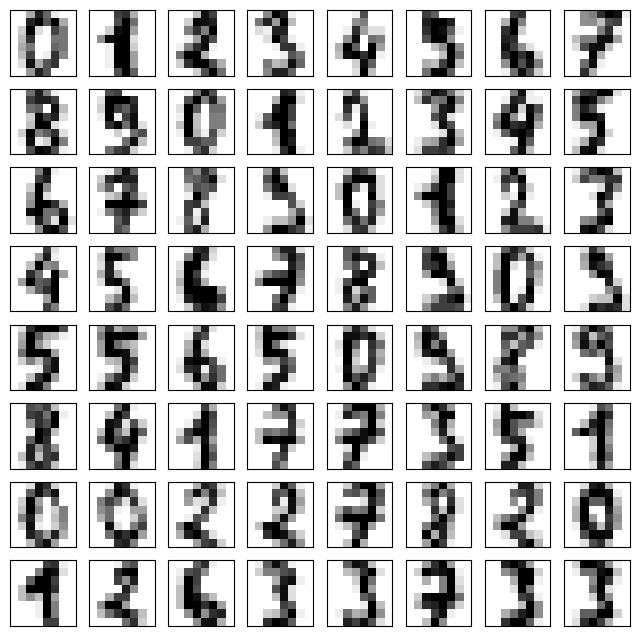

In [12]:
# Vẽ 64 ảnh đầu tiên
fig, ax = plt.subplots(8, 8, figsize=(8, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[i], cmap="binary")
    axi.set(xticks=[], yticks=[])
plt.savefig(OUT_DIR / "digits_64_anh.png", bbox_inches="tight")
plt.show()

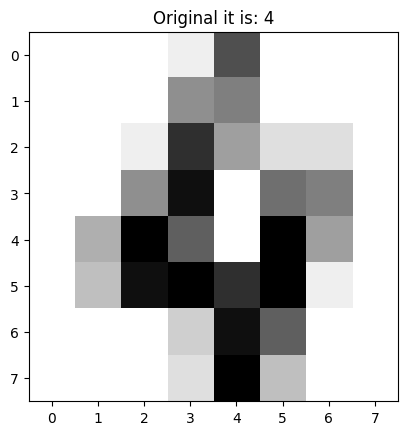

In [13]:
def view_digit(index):
    plt.imshow(digits.images[index], cmap=plt.cm.gray_r)
    plt.title("Original it is: " + str(digits.target[index]))
    plt.show()

view_digit(4)

## Nhiệm vụ 2.2: Xây dựng mô hình SVM nhận diện chữ viết tay

- `gamma=0.001`, `C=100`; huấn luyện 1500 ảnh đầu, kiểm tra trên các ảnh còn lại.
- Đã sửa 2 lỗi của code gốc: (1) `[1501:]` bỏ sót ảnh thứ 1500 → dùng `[1500:]`; (2) các hàm đánh giá của sklearn nhận `(y_true, y_pred)`, code gốc truyền ngược nên precision/recall bị đổi chỗ.

In [14]:
main_data, targets = digits["data"], digits["target"]
X_train, y_train = main_data[:1500], targets[:1500]
X_test, y_test = main_data[1500:], targets[1500:]

svc = svm.SVC(gamma=0.001, C=100)
svc.fit(X_train, y_train)
predictions = svc.predict(X_test)
print(f"Số ảnh kiểm tra: {len(y_test)} | Accuracy: {svc.score(X_test, y_test):.4f}")

Số ảnh kiểm tra: 297 | Accuracy: 0.9529


**Confusion matrix** (hàng = nhãn thực, cột = nhãn dự đoán):

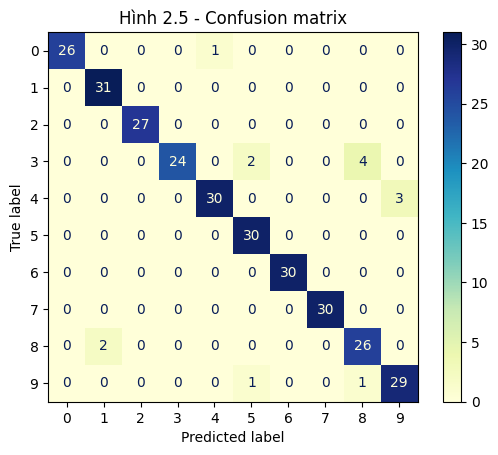

In [15]:
cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm).plot(cmap="YlGnBu", values_format="d")
plt.title("Hình 2.5 - Confusion matrix")
plt.savefig(OUT_DIR / "hinh_2_5_confusion_digits.png", bbox_inches="tight")
plt.show()

**Báo cáo phân loại** từng lớp (precision / recall / f1-score):

In [16]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.94      1.00      0.97        31
           2       1.00      1.00      1.00        27
           3       1.00      0.80      0.89        30
           4       0.97      0.91      0.94        33
           5       0.91      1.00      0.95        30
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.84      0.93      0.88        28
           9       0.91      0.94      0.92        31

    accuracy                           0.95       297
   macro avg       0.96      0.95      0.95       297
weighted avg       0.96      0.95      0.95       297



**Một số ảnh bị dự đoán sai:**

Số ảnh sai: 14


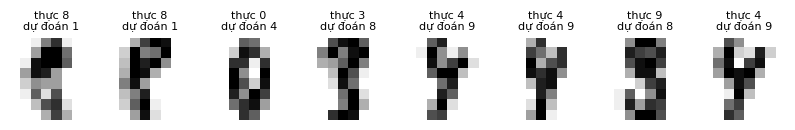

In [17]:
sai = np.where(predictions != y_test)[0]
print("Số ảnh sai:", len(sai))
fig, axs = plt.subplots(1, min(8, len(sai)), figsize=(10, 2))
for ax, idx in zip(np.atleast_1d(axs), sai[:8]):
    ax.imshow(digits.images[1500 + idx], cmap="gray_r")
    ax.set_title(f"thực {y_test[idx]}\ndự đoán {predictions[idx]}", fontsize=8)
    ax.axis("off")
plt.show()

## Nhiệm vụ 2.3 (mở rộng): Tìm `C` và `gamma` tối ưu

In [18]:
gs2 = GridSearchCV(svm.SVC(),
                   {"C": [1, 10, 100], "gamma": [0.0001, 0.001, 0.01], "kernel": ["rbf"]},
                   cv=5, n_jobs=-1)
gs2.fit(X_train, y_train)
print("Tham số tốt nhất:", gs2.best_params_)
print(f"Accuracy CV: {gs2.best_score_:.4f} | Accuracy test: {gs2.score(X_test, y_test):.4f}")
pd.DataFrame(gs2.cv_results_)[["param_C", "param_gamma", "mean_test_score"]].round(4)

Tham số tốt nhất: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Accuracy CV: 0.9800 | Accuracy test: 0.9529


,param_C,param_gamma,mean_test_score
0,1,0.0001,0.9460
1,1,0.0010,0.9767
2,1,0.0100,0.6933
3,10,0.0001,0.9713
4,10,0.0010,0.9800
5,10,0.0100,0.7013
6,100,0.0001,0.9667
7,100,0.0010,0.9800
8,100,0.0100,0.7013
